## **1. Import Library**

In [ ]:
# Pastiin ini dijalanin dulu ya
#!pip install scikit-learn-extra
#!pip install "numpy<2"

In [ ]:
# Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Memuat Dataset**

In [ ]:
# Load dataset hasil processing
url = "https://drive.google.com/uc?id=15xk83k4FAHyJAjnK4eqTpyn6N9dHtyxZ"
data = pd.read_csv(url)

#Hapus kolom year_month
data = data.drop('year_month', axis=1)

# Tampilkan data
data.head()

,amount,year,month,day,category_Bills & Fees,category_Food & Drinks,category_Transport,account_Cash,account_Metro Card,account_Salary Bank,account_Savings Bank,type_EXPENSE,type_INCOME,type_TRANSFER
0,45000.0,2024,8,11,True,False,False,False,False,False,True,True,False,False
1,40000.0,2024,8,10,False,True,False,True,False,False,False,True,False,False
2,10000.0,2024,8,9,False,False,True,True,False,False,False,True,False,False
3,200000.0,2024,8,7,True,False,False,False,False,False,True,True,False,False
4,4000.0,2024,8,4,True,False,False,False,False,True,False,False,True,False


## **3. Membangun Model**

1. Model Clustering (K-Medoids)

In [ ]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Elbow Method untuk K-Medoids
# k_range = range(2, 10)
# silhouette_scores = []
'''
for k in k_range:
    kmedoids = KMedoids(n_clusters=k, random_state=42)
    kmedoids.fit(data)
    score = silhouette_score(data, kmedoids.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score vs Jumlah Cluster (K-Medoids)')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Jumlah cluster terbaik: {best_k}")
'''

'\nfor k in k_range:\n    kmedoids = KMedoids(n_clusters=k, random_state=42)\n    kmedoids.fit(data)\n    score = silhouette_score(data, kmedoids.labels_)\n    silhouette_scores.append(score)\n\nplt.figure(figsize=(8, 4))\nplt.plot(k_range, silhouette_scores, marker=\'o\')\nplt.title(\'Silhouette Score vs Jumlah Cluster (K-Medoids)\')\nplt.xlabel(\'Jumlah Cluster (k)\')\nplt.ylabel(\'Silhouette Score\')\nplt.xticks(k_range)\nplt.grid(True)\nplt.show()\n\nbest_k = k_range[silhouette_scores.index(max(silhouette_scores))]\nprint(f"Jumlah cluster terbaik: {best_k}")\n'

In [ ]:
# Buat dan latih model K-Medoids
model_kmedoids = KMedoids(n_clusters=2, random_state=42)
model_kmedoids.fit(data)

KMedoids(n_clusters=2, random_state=42)

In [ ]:
# Menghitung dan menampilkan nilai Silhouette Score.

# Dapatkan hasil (label) cluster dari model 'kmedoids' yang telah di-fit
labels = model_kmedoids.labels_

# Panggil fungsi untuk menghitung silhouette score
# score = silhouette_score(data, labels)

# Cetak skornya
# print("Silhouette Score:", score)

In [ ]:
# Simpan Model K-Means
joblib.dump(model_kmedoids, 'model_kmedoids.pkl')

['model_kmedoids.pkl']

In [ ]:
data['Cluster'] = labels

numerical_cols = data.select_dtypes(include=['number']).columns
agg_summary = data.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

display(agg_summary)

Cluster               0          1
amount  mean   80442.07   87512.84
        min        0.00       0.00
        max   999000.00  940000.00
year    mean    2023.57    2023.52
        min     2023.00    2023.00
        max     2024.00    2024.00
month   mean       6.08       5.97
        min        1.00       1.00
        max       12.00      12.00
day     mean       7.43      23.45
        min        1.00      15.00
        max       15.00      31.00
Cluster mean       0.00       1.00
        min        0.00       1.00
        max        0.00       1.00

In [ ]:
# Save data hasil clustering
df_cluster = data.copy()

df_cluster

,amount,year,month,day,category_Bills & Fees,category_Food & Drinks,category_Transport,account_Cash,account_Metro Card,account_Salary Bank,account_Savings Bank,type_EXPENSE,type_INCOME,type_TRANSFER,Cluster
0,45000.0,2024,8,11,True,False,False,False,False,False,True,True,False,False,0
1,40000.0,2024,8,10,False,True,False,True,False,False,False,True,False,False,0
2,10000.0,2024,8,9,False,False,True,True,False,False,False,True,False,False,0
3,200000.0,2024,8,7,True,False,False,False,False,False,True,True,False,False,0
4,4000.0,2024,8,4,True,False,False,False,False,True,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1150,7000.0,2023,4,22,False,False,True,True,False,False,False,False,True,False,1
1151,300000.0,2023,4,22,False,False,True,False,False,False,True,False,True,False,1
1152,139000.0,2023,4,22,False,False,True,False,True,False,False,False,True,False,1
1153,35000.0,2023,4,22,False,False,True,False,False,False,True,False,True,False,1


In [ ]:
# Simpan data hasil clustering
df_cluster.to_csv('Financial_Transactions_Cluster.csv', index=False)

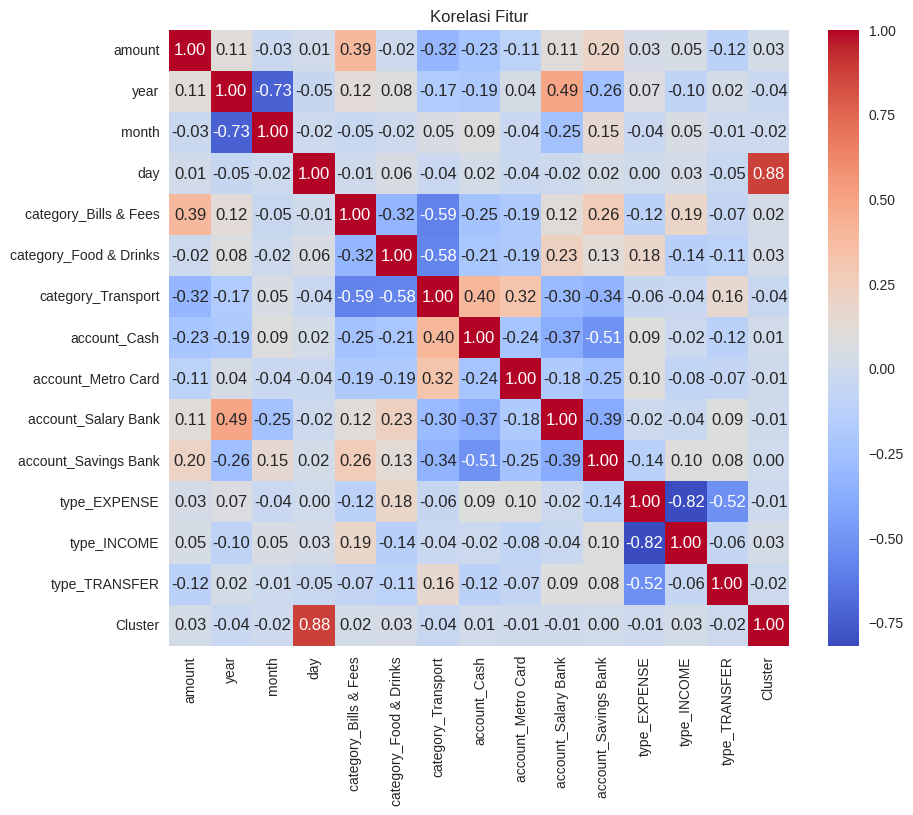

In [ ]:
# Grafik Korelasi Fitur
corr_matrix = df_cluster.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Fitur')
plt.show()

2. Model Klasifikasi

In [ ]:
# Menggunakan train_test_split() untuk melakukan pembagian dataset
X = df_cluster.drop('Cluster', axis=1)
y = df_cluster['Cluster']


# Panggil fungsi untuk membagi data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

### SELESAI CODE ###

print("Jumlah data total: ",len(X))
print("Jumlah data latih: ",len(X_train))
print("Jumlah data test: ",len(X_test))

Jumlah data total:  1155
Jumlah data latih:  924
Jumlah data test:  231


In [ ]:
# Latih Model decision tree
decision_tree_model = DecisionTreeClassifier(random_state=42)

# 2. Latih (fit) model dengan data training (X_train dan y_train)
decision_tree_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
# Menyimpan Model
joblib.dump(decision_tree_model, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

## 4. Evaluasi Akurasi dan Tuning Model

In [ ]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada seluruh algoritma yang sudah dibuat.

# Buat prediksi pada data 'X_test'
y_pred_dt = decision_tree_model.predict(X_test)

# Tampilkan classification_report
print("Decision Tree Performance")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00       128

    accuracy                           1.00       231
   macro avg       1.00      1.00      1.00       231
weighted avg       1.00      1.00      1.00       231



In [ ]:
# Lakukan Hyperparameter Tuning dan Latih ulang

# Tentukan Hyperparameter yang akan di-tuning
params = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Buat objek GridSearchCV
new_model_tuned = GridSearchCV(
    estimator = DecisionTreeClassifier(random_state=42),
    param_grid = params,
    cv = 5,
    scoring = 'accuracy'
)

# Latih model
new_model_tuned.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada algoritma yang sudah dituning.

# Buat prediksi pada 'X_test' Gunakan model yang sudah di-tuning
y_pred_tuning = new_model_tuned.predict(X_test)

# Tampilkan classification_report untuk model yang sudah di-tuning
print("Tuned Model Performance")
print(classification_report(y_test, y_pred_tuning))

Tuned Model Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00       128

    accuracy                           1.00       231
   macro avg       1.00      1.00      1.00       231
weighted avg       1.00      1.00      1.00       231



In [ ]:
y_pred_all = decision_tree_model.predict(X)

df_klasifikasi = df_cluster.copy()
df_klasifikasi['Cluster_Pred'] = y_pred_all

df_klasifikasi['Cluster_Pred']

,Cluster_Pred
0,0
1,0
2,0
3,0
4,0
...,...
1150,1
1151,1
1152,1
1153,1


In [ ]:
# Simpan data hasil klasifikasi
df_klasifikasi.to_csv('Financial_Transactions_Klasifikasi.csv', index=False)